<a href="https://colab.research.google.com/github/FatherNurt/FUNt-Cosmologiical-Model-of-All-Things/blob/main/FUNt_Transition_Engine_v0_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FUNt Transition Engine v0.1

**Domain-neutral core + earthquake adapter.**

This notebook begins the separation between:

- **Core transition mathematics**: perturbation, transport, accumulation, transition strain `S`, candidate transition, hHRT, hHRB, relaxation.
- **Domain adapters**: earthquake, solar weather, biology, etc.

The engine itself does **not** know what an earthquake is. The earthquake adapter translates USGS event data into standardized operator inputs.

**Status:** historical/descriptive only. No prediction performed.


In [1]:
# ============================================================
# FUNt Transition Engine v0.1
# Domain-neutral core + Earthquake Adapter
# Historical / descriptive analysis only. No prediction performed.
# ============================================================

import requests
import json
import hashlib
import os
import zipfile
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import files
    IN_COLAB = True
except Exception:
    IN_COLAB = False

try:
    from IPython.display import display, Image
    IN_IPYTHON = True
except Exception:
    IN_IPYTHON = False

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)


## 1. Configuration

Change only this block for a new run.

The core engine fields are domain-neutral. The adapter fields tell the notebook how to acquire and translate earthquake data.


In [2]:
CONFIG = {
    "engine_version": "FUNt Transition Engine v0.1",
    "run_label": "venezuela_us6000t7zp_engine_test",
    "prediction_mode": False,

    # Domain adapter
    "domain": "earthquake",
    "adapter_version": "Earthquake Adapter v0.1 - USGS",
    "event_id": "us6000t7zp",
    "source": "USGS FDSN Event API",
    "min_magnitude": 4.0,
    "max_radius_km": 500,
    "days_after_event_transition": 30,
    "distance_bands_km": [0, 100, 250, 500],

    # Local clock reference
    "local_time_zone": "America/Caracas",
    "local_time_label": "Venezuela Time / VET",

    # Engine parameters
    "hourly_bin_size_hours": 1,
    "rolling_window_hours": 6,
    "survival_windows_x": 3,
    "small_catalog_warning_threshold": 10,

    # Transition strain S weights. These are explicit v0.1 engineering weights,
    # not claimed as final theory.
    "S_weights": {
        "perturbation": 0.40,
        "transport": 0.20,
        "accumulation": 0.25,
        "persistence": 0.15
    },

    # Candidate thresholds in normalized S-space.
    # h3pi is NOT hard-coded as a trigger. It is retained as an audit reference only.
    "candidate_transition_S_threshold": 0.70,
    "hHRT_tau_hours": 3,
    "hHRB_requires_survival_windows": True,
    "h3pi_audit_reference": float(3 * np.pi),
}

CONFIG_JSON = json.dumps(CONFIG, sort_keys=True)
CONFIG_HASH = hashlib.sha256(CONFIG_JSON.encode("utf-8")).hexdigest()

print("==== FUNt Transition Engine Audit Header ====")
print(json.dumps(CONFIG, indent=2))
print("\nConfig SHA-256:", CONFIG_HASH)
print("Prediction mode:", CONFIG["prediction_mode"])


==== FUNt Transition Engine Audit Header ====
{
  "engine_version": "FUNt Transition Engine v0.1",
  "run_label": "venezuela_us6000t7zp_engine_test",
  "prediction_mode": false,
  "domain": "earthquake",
  "adapter_version": "Earthquake Adapter v0.1 - USGS",
  "event_id": "us6000t7zp",
  "source": "USGS FDSN Event API",
  "min_magnitude": 4.0,
  "max_radius_km": 500,
  "days_after_event_transition": 30,
  "distance_bands_km": [
    0,
    100,
    250,
    500
  ],
  "local_time_zone": "America/Caracas",
  "local_time_label": "Venezuela Time / VET",
  "hourly_bin_size_hours": 1,
  "rolling_window_hours": 6,
  "survival_windows_x": 3,
  "small_catalog_warning_threshold": 10,
  "S_weights": {
    "perturbation": 0.4,
    "transport": 0.2,
    "accumulation": 0.25,
    "persistence": 0.15
  },
  "candidate_transition_S_threshold": 0.7,
  "hHRT_tau_hours": 3,
  "hHRB_requires_survival_windows": true,
  "h3pi_audit_reference": 9.42477796076938
}

Config SHA-256: a71ae54ce8aa54ad73f3a00263ae

## 2. Domain-Neutral Helper Functions

In [3]:
def ensure_dir(path):
    os.makedirs(path, exist_ok=True)
    return path


def save_json(path, obj):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, default=str)


def write_text(path, text):
    with open(path, "w", encoding="utf-8") as f:
        f.write(text)


def robust_minmax(series, lower_q=0.02, upper_q=0.98):
    """Robust 0-1 normalization with quantile clipping."""
    s = pd.Series(series).astype(float)
    if s.empty or s.notna().sum() == 0:
        return pd.Series(np.zeros(len(s)), index=s.index)
    lo = s.quantile(lower_q)
    hi = s.quantile(upper_q)
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return ((s.clip(lo, hi) - lo) / (hi - lo)).fillna(0)


def safe_divide(a, b, eps=1e-12):
    return np.asarray(a, dtype=float) / (np.asarray(b, dtype=float) + eps)


def catalog_maturity(n, threshold=10):
    if n < threshold:
        return "Preliminary"
    if n < 50:
        return "Developing"
    if n < 200:
        return "Moderate"
    if n < 1000:
        return "Mature"
    return "Research grade"


def rolling_survival(active_series, x):
    return pd.Series(active_series).rolling(x, min_periods=x).sum() >= x


## 3. Earthquake Adapter Functions

The adapter converts USGS earthquake data into a standardized event table.

The core engine receives only standardized fields.


In [4]:
def usgs_get_json(url, timeout=30):
    r = requests.get(url, timeout=timeout)
    r.raise_for_status()
    return r.json()


def mag_to_energy_joules(m):
    # Gutenberg-Richter energy estimate: E = 10^(1.5M + 4.8) Joules.
    if pd.isna(m):
        return np.nan
    return 10 ** (1.5 * float(m) + 4.8)


def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0088
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2.0)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2.0)**2
    return 2 * R * np.arcsin(np.sqrt(a))


def fetch_usgs_mainquake(event_id):
    url = "https://earthquake.usgs.gov/fdsnws/event/1/query?" + f"format=geojson&eventid={event_id}"
    geojson = usgs_get_json(url)
    props = geojson["properties"]
    coords = geojson["geometry"]["coordinates"]

    return {
        "event_id": event_id,
        "place": props.get("place"),
        "magnitude": props.get("mag"),
        "time_ms": props.get("time"),
        "time_utc": pd.to_datetime(props.get("time"), unit="ms", utc=True),
        "longitude": coords[0],
        "latitude": coords[1],
        "depth_km": coords[2],
        "url": props.get("url"),
    }


def fetch_usgs_aftershocks(config, event_transition):
    main_time = event_transition["time_utc"]
    end_time = main_time + pd.Timedelta(days=config["days_after_event_transition"])

    starttime = main_time.strftime("%Y-%m-%dT%H:%M:%S")
    endtime = end_time.strftime("%Y-%m-%dT%H:%M:%S")

    query_url = (
        "https://earthquake.usgs.gov/fdsnws/event/1/query?"
        f"format=geojson&starttime={starttime}&endtime={endtime}"
        f"&minmagnitude={config['min_magnitude']}"
        f"&latitude={event_transition['latitude']}&longitude={event_transition['longitude']}"
        f"&maxradiuskm={config['max_radius_km']}"
        "&orderby=time-asc"
    )

    retrieval_time_utc = datetime.now(timezone.utc).isoformat()
    geojson = usgs_get_json(query_url)
    features = geojson.get("features", [])

    rows = []
    rejected_mainquake = 0
    rejected_before_transition = 0

    for f in features:
        fid = f.get("id")
        p = f.get("properties", {})
        g = f.get("geometry", {}).get("coordinates", [np.nan, np.nan, np.nan])
        event_time = pd.to_datetime(p.get("time"), unit="ms", utc=True)

        if fid == config["event_id"]:
            rejected_mainquake += 1
            continue
        if event_time < main_time:
            rejected_before_transition += 1
            continue

        lon, lat, depth = g[0], g[1], g[2]
        distance_km = haversine_km(event_transition["latitude"], event_transition["longitude"], lat, lon)
        hours_since = (event_time - main_time).total_seconds() / 3600.0
        mag = p.get("mag")

        rows.append({
            "event_id": fid,
            "time_utc": event_time,
            "hours_since_event_transition": hours_since,
            "magnitude": mag,
            "energy_J": mag_to_energy_joules(mag),
            "place": p.get("place"),
            "latitude": lat,
            "longitude": lon,
            "depth_km": depth,
            "distance_km": distance_km,
            "usgs_url": p.get("url"),
        })

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values("time_utc").reset_index(drop=True)
        df["cumulative_energy_J"] = df["energy_J"].cumsum()
        df["hour_bin"] = np.floor(df["hours_since_event_transition"]).astype(int)

    audit = {
        "query_url": query_url,
        "retrieval_time_utc": retrieval_time_utc,
        "raw_events_retrieved": len(features),
        "rejected_as_mainquake": rejected_mainquake,
        "rejected_before_transition": rejected_before_transition,
        "aftershocks_analyzed": len(df),
    }
    return df, audit


## 4. Run Earthquake Adapter

In [5]:
EVENT_TRANSITION = fetch_usgs_mainquake(CONFIG["event_id"])

# Add local Venezuela time reference.
EVENT_TRANSITION["time_local"] = EVENT_TRANSITION["time_utc"].tz_convert(CONFIG["local_time_zone"])
now_utc = pd.Timestamp.now(tz="UTC")
now_local = now_utc.tz_convert(CONFIG["local_time_zone"])
clock_reference = {
    "clock_zone": CONFIG["local_time_label"],
    "iana_time_zone": CONFIG["local_time_zone"],
    "event_transition_local_time": EVENT_TRANSITION["time_local"].strftime("%Y-%m-%d %I:%M:%S %p %z"),
    "current_local_time_at_runtime": now_local.strftime("%Y-%m-%d %I:%M:%S %p %z"),
    "realtime_hours_since_event_transition": float((now_utc - EVENT_TRANSITION["time_utc"]).total_seconds() / 3600),
    "realtime_days_since_event_transition": float((now_utc - EVENT_TRANSITION["time_utc"]).total_seconds() / (3600*24)),
}

df_events, acquisition_audit = fetch_usgs_aftershocks(CONFIG, EVENT_TRANSITION)

print("==== Event Transition Anchor ====")
for k, v in EVENT_TRANSITION.items():
    print(f"{k}: {v}")

print("\n==== Local Clock Reference ====")
for k, v in clock_reference.items():
    print(f"{k}: {v}")

print("\n==== Data Acquisition Audit ====")
for k, v in acquisition_audit.items():
    print(f"{k}: {v}")

df_events.head()


==== Event Transition Anchor ====
event_id: us6000t7zp
place: 28 km SE of Yumare, Venezuela
magnitude: 7.5
time_ms: 1782338711566
time_utc: 2026-06-24 22:05:11.566000+00:00
longitude: -68.4716
latitude: 10.4351
depth_km: 10
url: https://earthquake.usgs.gov/earthquakes/eventpage/us6000t7zp
time_local: 2026-06-24 18:05:11.566000-04:00

==== Local Clock Reference ====
clock_zone: Venezuela Time / VET
iana_time_zone: America/Caracas
event_transition_local_time: 2026-06-24 06:05:11 PM -0400
current_local_time_at_runtime: 2026-06-26 07:39:24 PM -0400
realtime_hours_since_event_transition: 49.570275271944446
realtime_days_since_event_transition: 2.0654281363310183

==== Data Acquisition Audit ====
query_url: https://earthquake.usgs.gov/fdsnws/event/1/query?format=geojson&starttime=2026-06-24T22:05:11&endtime=2026-07-24T22:05:11&minmagnitude=4.0&latitude=10.4351&longitude=-68.4716&maxradiuskm=500&orderby=time-asc
retrieval_time_utc: 2026-06-26T23:39:24.557753+00:00
raw_events_retrieved: 5
reje

,event_id,time_utc,hours_since_event_transition,magnitude,energy_J,place,latitude,longitude,depth_km,distance_km,usgs_url,cumulative_energy_J,hour_bin
0,us6000t80d,2026-06-24 22:23:54.046000+00:00,0.311800,4.5,3.548134e+11,"13 km N of Caucagüito, Venezuela",10.6092,-66.7168,10,192.817940,https://earthquake.usgs.gov/earthquakes/eventp...,3.548134e+11,0
1,us6000t81p,2026-06-25 05:48:23.136000+00:00,7.719881,4.4,2.511886e+11,"5 km NE of Guatire, Venezuela",10.5111,-66.5057,10,215.122326,https://earthquake.usgs.gov/earthquakes/eventp...,6.060020e+11,7
2,us6000t8d1,2026-06-26 04:19:30.378000+00:00,30.238559,4.4,2.511886e+11,"17 km WSW of Morón, Venezuela",10.4537,-68.3607,10,12.302315,https://earthquake.usgs.gov/earthquakes/eventp...,8.571907e+11,30
3,us6000t8k6,2026-06-26 22:16:11.931000+00:00,48.183435,4.7,7.079458e+11,"54 km N of El Limón, Venezuela",10.8000,-67.5993,10,103.609954,https://earthquake.usgs.gov/earthquakes/eventp...,1.565136e+12,48


## 5. FUNt Transition Engine Core

The engine consumes standardized event observations and computes domain-neutral operator ledgers.

### Operator Inputs

- `P`: perturbation intensity
- `T`: transport / spatial migration proxy
- `A`: accumulation proxy
- `R`: recurrence / persistence proxy
- `S`: transition strain

In v0.1, `S` is an explicit engineering composite. It is not claimed as the final mathematical form.


In [6]:
def build_hourly_base(df_events, config):
    if df_events.empty:
        return pd.DataFrame()

    max_hour = int(np.ceil(df_events["hours_since_event_transition"].max()))
    full_hours = pd.DataFrame({"hour": np.arange(0, max_hour + 1)})

    grouped = (
        df_events.groupby("hour_bin")
        .agg(
            event_count=("event_id", "count"),
            energy_J=("energy_J", "sum"),
            max_magnitude=("magnitude", "max"),
            mean_magnitude=("magnitude", "mean"),
            mean_depth_km=("depth_km", "mean"),
            mean_distance_km=("distance_km", "mean"),
        )
        .rename_axis("hour")
        .reset_index()
    )

    dfh = full_hours.merge(grouped, on="hour", how="left")
    dfh["event_count"] = dfh["event_count"].fillna(0).astype(int)
    dfh["energy_J"] = dfh["energy_J"].fillna(0.0)
    dfh["max_magnitude"] = dfh["max_magnitude"].fillna(0.0)
    dfh["mean_magnitude"] = dfh["mean_magnitude"].fillna(0.0)
    dfh["mean_depth_km"] = dfh["mean_depth_km"].ffill().bfill().fillna(0.0)
    dfh["mean_distance_km"] = dfh["mean_distance_km"].ffill().bfill().fillna(0.0)
    dfh["cumulative_energy_J"] = dfh["energy_J"].cumsum()
    dfh["cumulative_event_count"] = dfh["event_count"].cumsum()

    return dfh


def run_transition_engine(df_events, config):
    dfh = build_hourly_base(df_events, config)
    if dfh.empty:
        return dfh, {"status": "no events"}

    w = config["rolling_window_hours"]
    x = config["survival_windows_x"]
    weights = config["S_weights"]

    # Operator components.
    # P: perturbation intensity from hourly energy and max magnitude.
    dfh["P_energy_norm"] = robust_minmax(np.log10(dfh["energy_J"] + 1))
    dfh["P_mag_norm"] = robust_minmax(dfh["max_magnitude"])
    dfh["P_perturbation"] = 0.65 * dfh["P_energy_norm"] + 0.35 * dfh["P_mag_norm"]

    # T: transport/spatial migration proxy from distance/depth movement.
    dfh["distance_delta_km"] = dfh["mean_distance_km"].diff().abs().fillna(0)
    dfh["depth_delta_km"] = dfh["mean_depth_km"].diff().abs().fillna(0)
    dfh["T_distance_norm"] = robust_minmax(dfh["distance_delta_km"])
    dfh["T_depth_norm"] = robust_minmax(dfh["depth_delta_km"])
    dfh["T_transport"] = 0.70 * dfh["T_distance_norm"] + 0.30 * dfh["T_depth_norm"]

    # A: accumulation proxy from cumulative energy and rolling energy.
    dfh["rolling_energy_J"] = dfh["energy_J"].rolling(w, min_periods=1).sum()
    dfh["A_cum_energy_norm"] = robust_minmax(np.log10(dfh["cumulative_energy_J"] + 1))
    dfh["A_roll_energy_norm"] = robust_minmax(np.log10(dfh["rolling_energy_J"] + 1))
    dfh["A_accumulation"] = 0.50 * dfh["A_cum_energy_norm"] + 0.50 * dfh["A_roll_energy_norm"]

    # R: recurrence/persistence proxy.
    dfh["active_window"] = dfh["event_count"] > 0
    dfh["rolling_event_count"] = dfh["event_count"].rolling(w, min_periods=1).sum()
    dfh["R_event_norm"] = robust_minmax(dfh["rolling_event_count"])
    dfh["survival_x_windows"] = rolling_survival(dfh["active_window"], x).fillna(False)
    dfh["R_persistence"] = 0.65 * dfh["R_event_norm"] + 0.35 * dfh["survival_x_windows"].astype(float)

    # Transition strain S.
    dfh["S_transition_strain"] = (
        weights["perturbation"] * dfh["P_perturbation"] +
        weights["transport"] * dfh["T_transport"] +
        weights["accumulation"] * dfh["A_accumulation"] +
        weights["persistence"] * dfh["R_persistence"]
    )

    dfh["dS_dt"] = dfh["S_transition_strain"].diff().fillna(0)
    dfh["d2S_dt2"] = dfh["dS_dt"].diff().fillna(0)

    # Candidate transition is based on S crossing threshold, not on h3pi.
    threshold = config["candidate_transition_S_threshold"]
    dfh["candidate_transition"] = dfh["S_transition_strain"] >= threshold

    # hHRT: transition response window after candidate transition.
    tau = int(config["hHRT_tau_hours"])
    dfh["hHRT_active"] = False
    candidate_hours = dfh.loc[dfh["candidate_transition"], "hour"].astype(int).tolist()
    for h in candidate_hours:
        dfh.loc[(dfh["hour"] >= h) & (dfh["hour"] <= h + tau), "hHRT_active"] = True

    # hHRB: persistent response, currently requires survival windows while hHRT is active.
    if config["hHRB_requires_survival_windows"]:
        dfh["hHRB_active"] = dfh["hHRT_active"] & dfh["survival_x_windows"]
    else:
        dfh["hHRB_active"] = dfh["hHRT_active"] & (dfh["R_persistence"] > 0.5)

    # Relaxation: S declining after hHRT activity.
    dfh["relaxing"] = (dfh["dS_dt"] < 0) & (~dfh["candidate_transition"])

    def phase(row):
        if row["hHRB_active"]:
            return "hHRB"
        if row["hHRT_active"]:
            return "hHRT"
        if row["candidate_transition"]:
            return "Candidate Transition"
        if row["relaxing"]:
            return "Relaxation"
        if row["active_window"]:
            return "Perturbation"
        return "Quiescent"

    dfh["dominant_operator"] = dfh.apply(phase, axis=1)

    # Trigger geometry from discovered candidate-transition hours.
    candidate_transition_hours = dfh.loc[dfh["candidate_transition"], "hour"].astype(int).tolist()
    intervals = np.diff(candidate_transition_hours) if len(candidate_transition_hours) >= 2 else np.array([])
    ratios = intervals[1:] / intervals[:-1] if len(intervals) >= 2 else np.array([])
    phi = (1 + np.sqrt(5)) / 2

    if len(ratios) > 0:
        close_to_phi_pct = 100 * np.sum(np.abs(ratios - phi) < 0.15) / len(ratios)
        close_to_phi2_pct = 100 * np.sum(np.abs(ratios - phi**2) < 0.3) / len(ratios)
        close_to_invphi_pct = 100 * np.sum(np.abs(ratios - (phi - 1)) < 0.15) / len(ratios)
    else:
        close_to_phi_pct = np.nan
        close_to_phi2_pct = np.nan
        close_to_invphi_pct = np.nan

    diagnostics = {
        "candidate_transition_hours": candidate_transition_hours,
        "candidate_transition_count": len(candidate_transition_hours),
        "hHRT_active_hours": int(dfh["hHRT_active"].sum()),
        "hHRB_active_hours": int(dfh["hHRB_active"].sum()),
        "max_S_hour": int(dfh.loc[dfh["S_transition_strain"].idxmax(), "hour"]),
        "max_S_value": float(dfh["S_transition_strain"].max()),
        "max_dS_dt_hour": int(dfh.loc[dfh["dS_dt"].idxmax(), "hour"]),
        "max_dS_dt_value": float(dfh["dS_dt"].max()),
        "inter_candidate_intervals": intervals.tolist(),
        "interval_ratios": ratios.tolist(),
        "close_to_phi_pct": close_to_phi_pct,
        "close_to_phi2_pct": close_to_phi2_pct,
        "close_to_1_over_phi_pct": close_to_invphi_pct,
        "trigger_geometry_status": "ok" if len(candidate_transition_hours) >= 2 else "insufficient candidate transitions",
    }

    return dfh, diagnostics


df_engine, engine_diagnostics = run_transition_engine(df_events, CONFIG)

print("==== Engine Diagnostics ====")
for k, v in engine_diagnostics.items():
    print(f"{k}: {v}")

df_engine.head(12)


==== Engine Diagnostics ====
candidate_transition_hours: [30, 48]
candidate_transition_count: 2
hHRT_active_hours: 6
hHRB_active_hours: 0
max_S_hour: 48
max_S_value: 0.8841619446917187
max_dS_dt_hour: 48
max_dS_dt_value: 0.809870554262963
inter_candidate_intervals: [18]
interval_ratios: []
close_to_phi_pct: nan
close_to_phi2_pct: nan
close_to_1_over_phi_pct: nan
trigger_geometry_status: ok


,hour,event_count,energy_J,max_magnitude,mean_magnitude,mean_depth_km,mean_distance_km,cumulative_energy_J,cumulative_event_count,P_energy_norm,P_mag_norm,P_perturbation,distance_delta_km,depth_delta_km,T_distance_norm,T_depth_norm,T_transport,rolling_energy_J,A_cum_energy_norm,A_roll_energy_norm,A_accumulation,active_window,rolling_event_count,R_event_norm,survival_x_windows,R_persistence,S_transition_strain,dS_dt,d2S_dt2,candidate_transition,hHRT_active,hHRB_active,relaxing,dominant_operator
0,0,1,3.548134e+11,4.5,4.5,10.0,192.817940,3.548134e+11,1,0.999481,0.999112,0.999352,0.000000,0.0,0.000000,0.0,0.000000,3.548134e+11,0.000000,0.974684,0.487342,True,1.0,1.0,False,0.65,0.619076,0.000000,0.000000,False,False,False,False,Perturbation
1,1,0,0.000000e+00,0.0,0.0,10.0,192.817940,3.548134e+11,1,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,3.548134e+11,0.000000,0.974684,0.487342,False,1.0,1.0,False,0.65,0.219335,-0.399741,-0.399741,False,False,False,True,Relaxation
2,2,0,0.000000e+00,0.0,0.0,10.0,192.817940,3.548134e+11,1,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,3.548134e+11,0.000000,0.974684,0.487342,False,1.0,1.0,False,0.65,0.219335,0.000000,0.399741,False,False,False,False,Quiescent
3,3,0,0.000000e+00,0.0,0.0,10.0,192.817940,3.548134e+11,1,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,3.548134e+11,0.000000,0.974684,0.487342,False,1.0,1.0,False,0.65,0.219335,0.000000,0.000000,False,False,False,False,Quiescent
4,4,0,0.000000e+00,0.0,0.0,10.0,192.817940,3.548134e+11,1,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,3.548134e+11,0.000000,0.974684,0.487342,False,1.0,1.0,False,0.65,0.219335,0.000000,0.000000,False,False,False,False,Quiescent
5,5,0,0.000000e+00,0.0,0.0,10.0,192.817940,3.548134e+11,1,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,3.548134e+11,0.000000,0.974684,0.487342,False,1.0,1.0,False,0.65,0.219335,0.000000,0.000000,False,False,False,False,Quiescent
6,6,0,0.000000e+00,0.0,0.0,10.0,192.817940,3.548134e+11,1,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000e+00,0.000000,0.000000,0.000000,False,0.0,0.0,False,0.00,0.000000,-0.219335,-0.219335,False,False,False,True,Relaxation
7,7,1,2.511886e+11,4.4,4.4,10.0,215.122326,6.060020e+11,2,0.986501,0.976909,0.983144,22.304386,0.0,0.238453,0.0,0.166917,2.511886e+11,0.360675,0.962025,0.661350,True,1.0,1.0,False,0.65,0.689478,0.689478,0.908814,False,False,False,False,Perturbation
8,8,0,0.000000e+00,0.0,0.0,10.0,215.122326,6.060020e+11,2,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,2.511886e+11,0.360675,0.962025,0.661350,False,1.0,1.0,False,0.65,0.262838,-0.426641,-1.116119,False,False,False,True,Relaxation
9,9,0,0.000000e+00,0.0,0.0,10.0,215.122326,6.060020e+11,2,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,2.511886e+11,0.360675,0.962025,0.661350,False,1.0,1.0,False,0.65,0.262838,0.000000,0.426641,False,False,False,False,Quiescent


## 6. Export Ledgers and Audit Files

In [7]:
ROOT_DIR = ensure_dir("FUNt_Transition_Engine")
RUN_DIR = ensure_dir(os.path.join(ROOT_DIR, CONFIG["run_label"]))
FIG_DIR = ensure_dir(os.path.join(RUN_DIR, "figures"))

save_json(os.path.join(RUN_DIR, "config.json"), CONFIG)
save_json(os.path.join(RUN_DIR, "event_transition.json"), EVENT_TRANSITION)
save_json(os.path.join(RUN_DIR, "clock_reference.json"), clock_reference)
save_json(os.path.join(RUN_DIR, "acquisition_audit.json"), acquisition_audit)
save_json(os.path.join(RUN_DIR, "engine_diagnostics.json"), engine_diagnostics)
write_text(os.path.join(RUN_DIR, "SHA256.txt"), CONFIG_HASH + "\n")

if not df_events.empty:
    df_events.to_csv(os.path.join(RUN_DIR, "domain_events_earthquake.csv"), index=False)
if not df_engine.empty:
    df_engine.to_csv(os.path.join(RUN_DIR, "transition_engine_ledger.csv"), index=False)

print("Run directory:", RUN_DIR)
print("Saved core ledgers and audit files.")


Run directory: FUNt_Transition_Engine/venezuela_us6000t7zp_engine_test
Saved core ledgers and audit files.


## 7. Figures

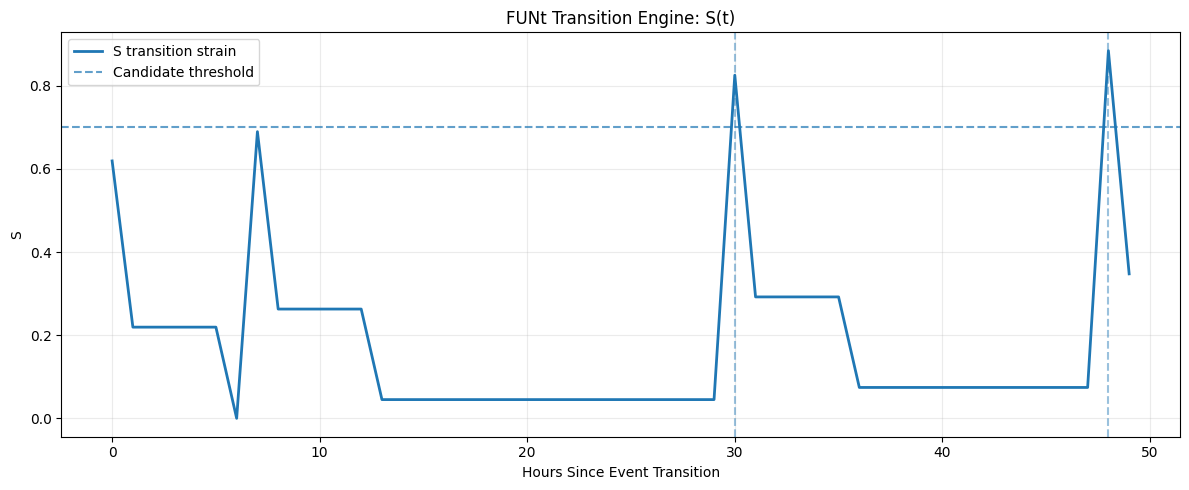

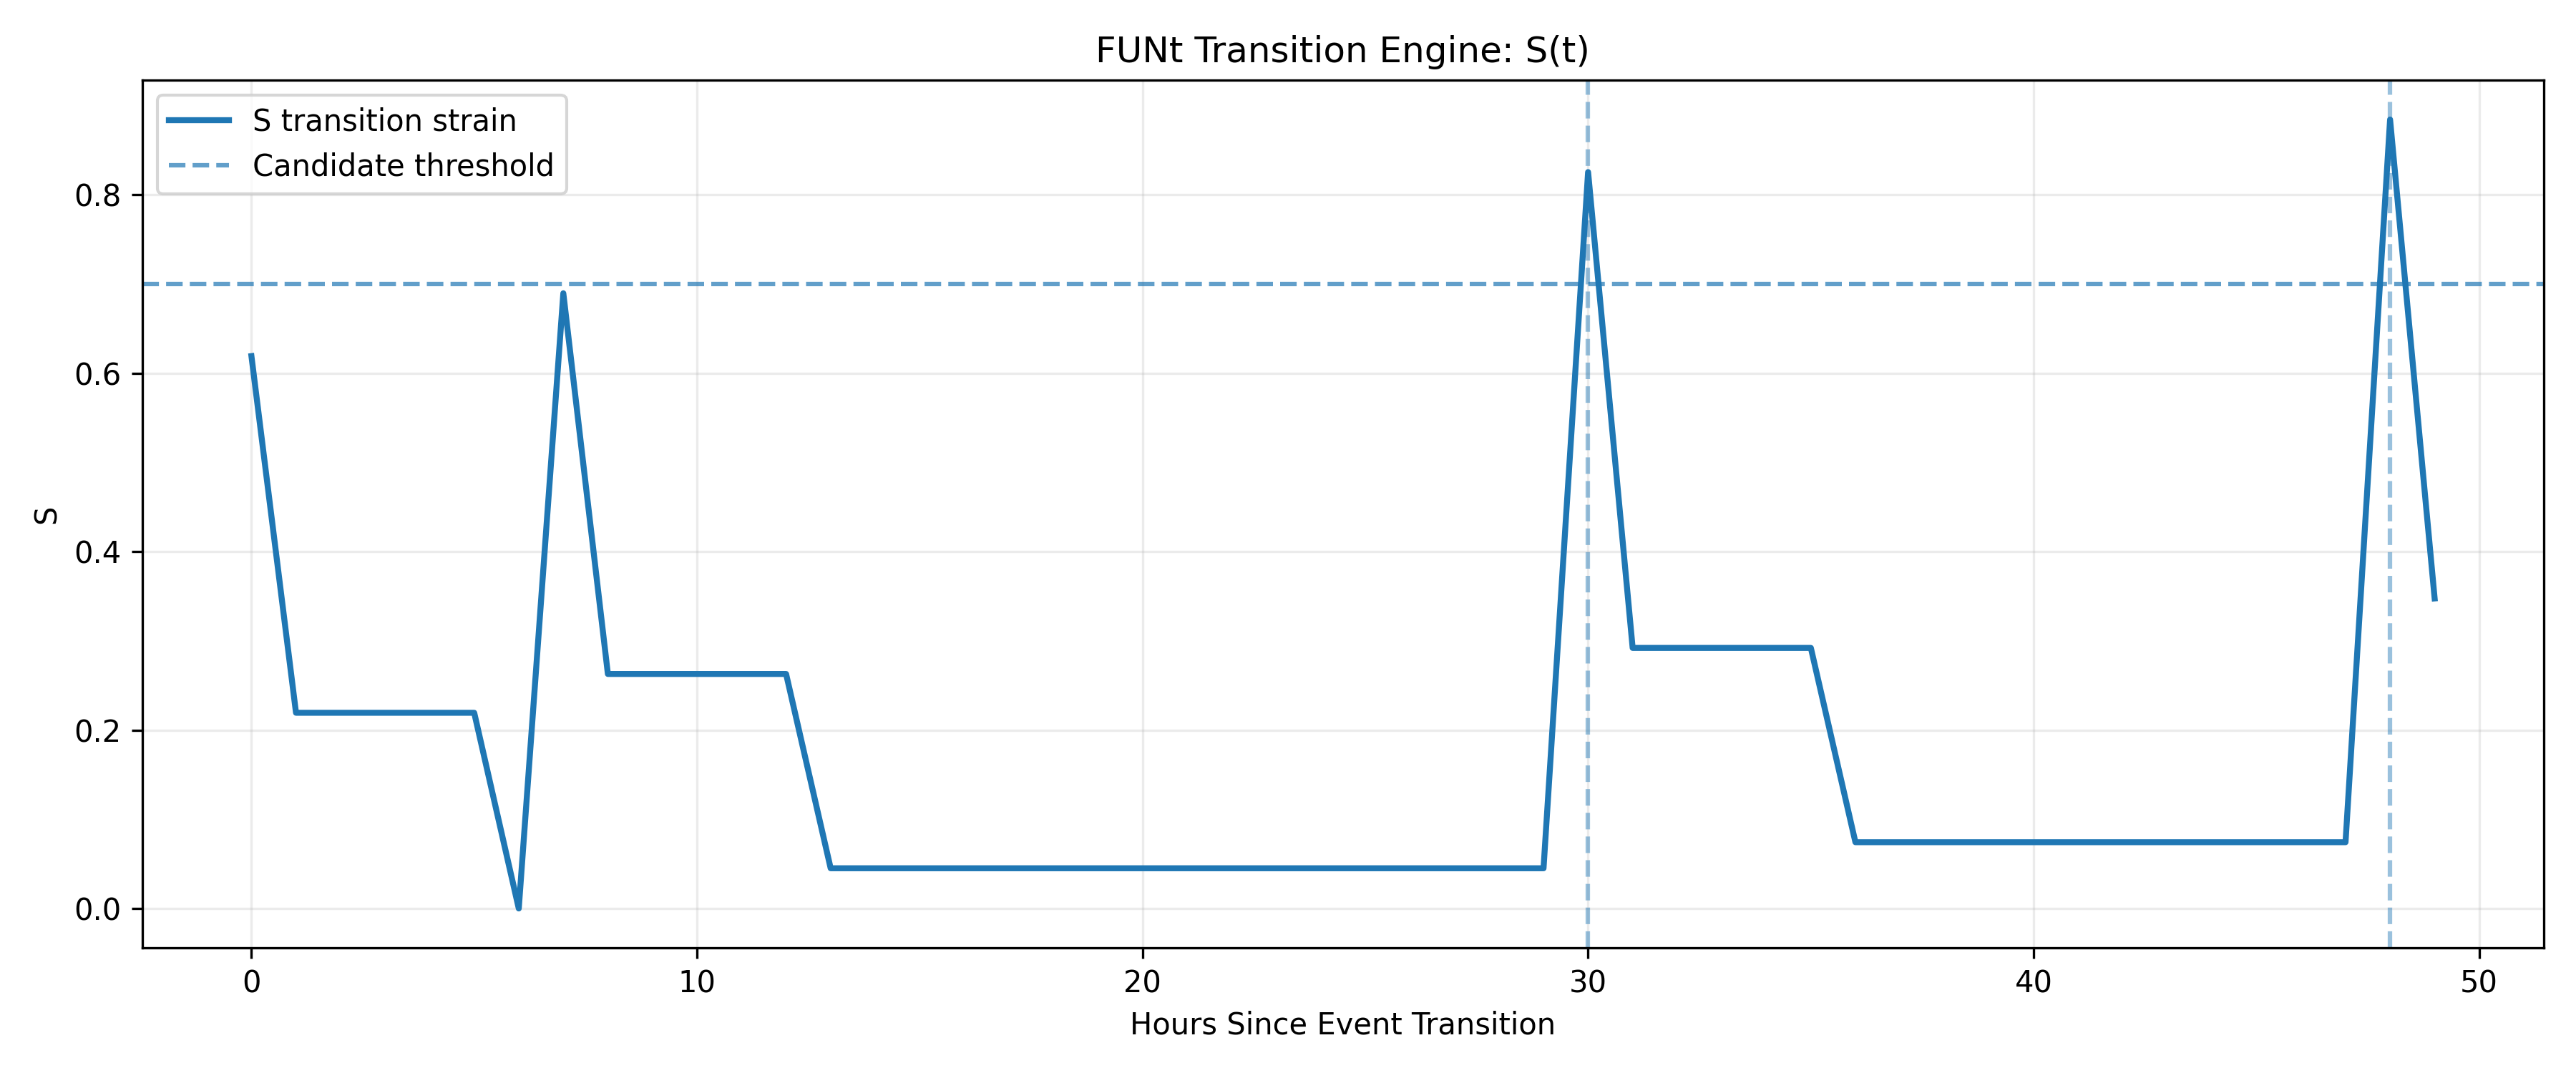

Saved: FUNt_Transition_Engine/venezuela_us6000t7zp_engine_test/figures/S_transition_strain.png


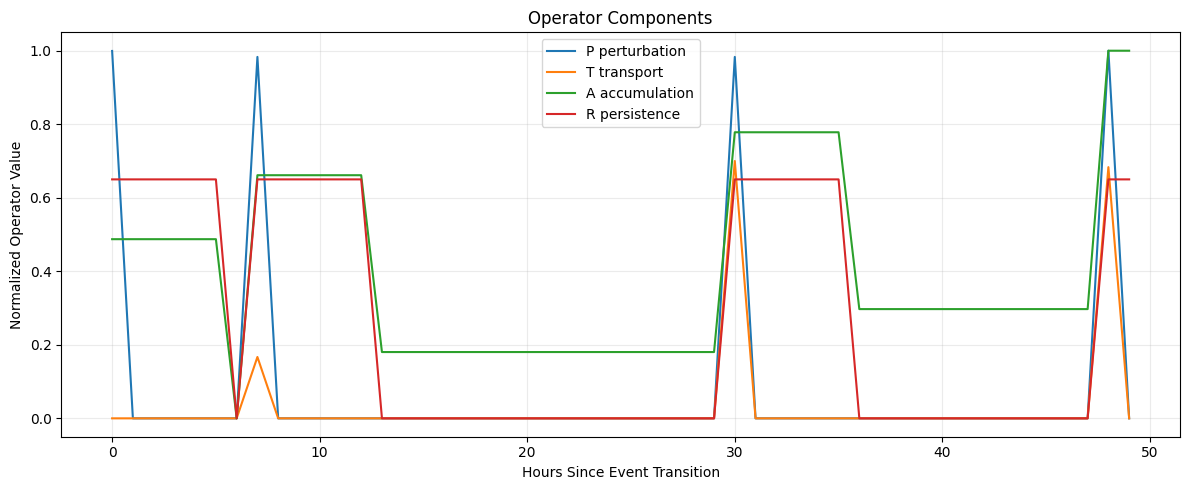

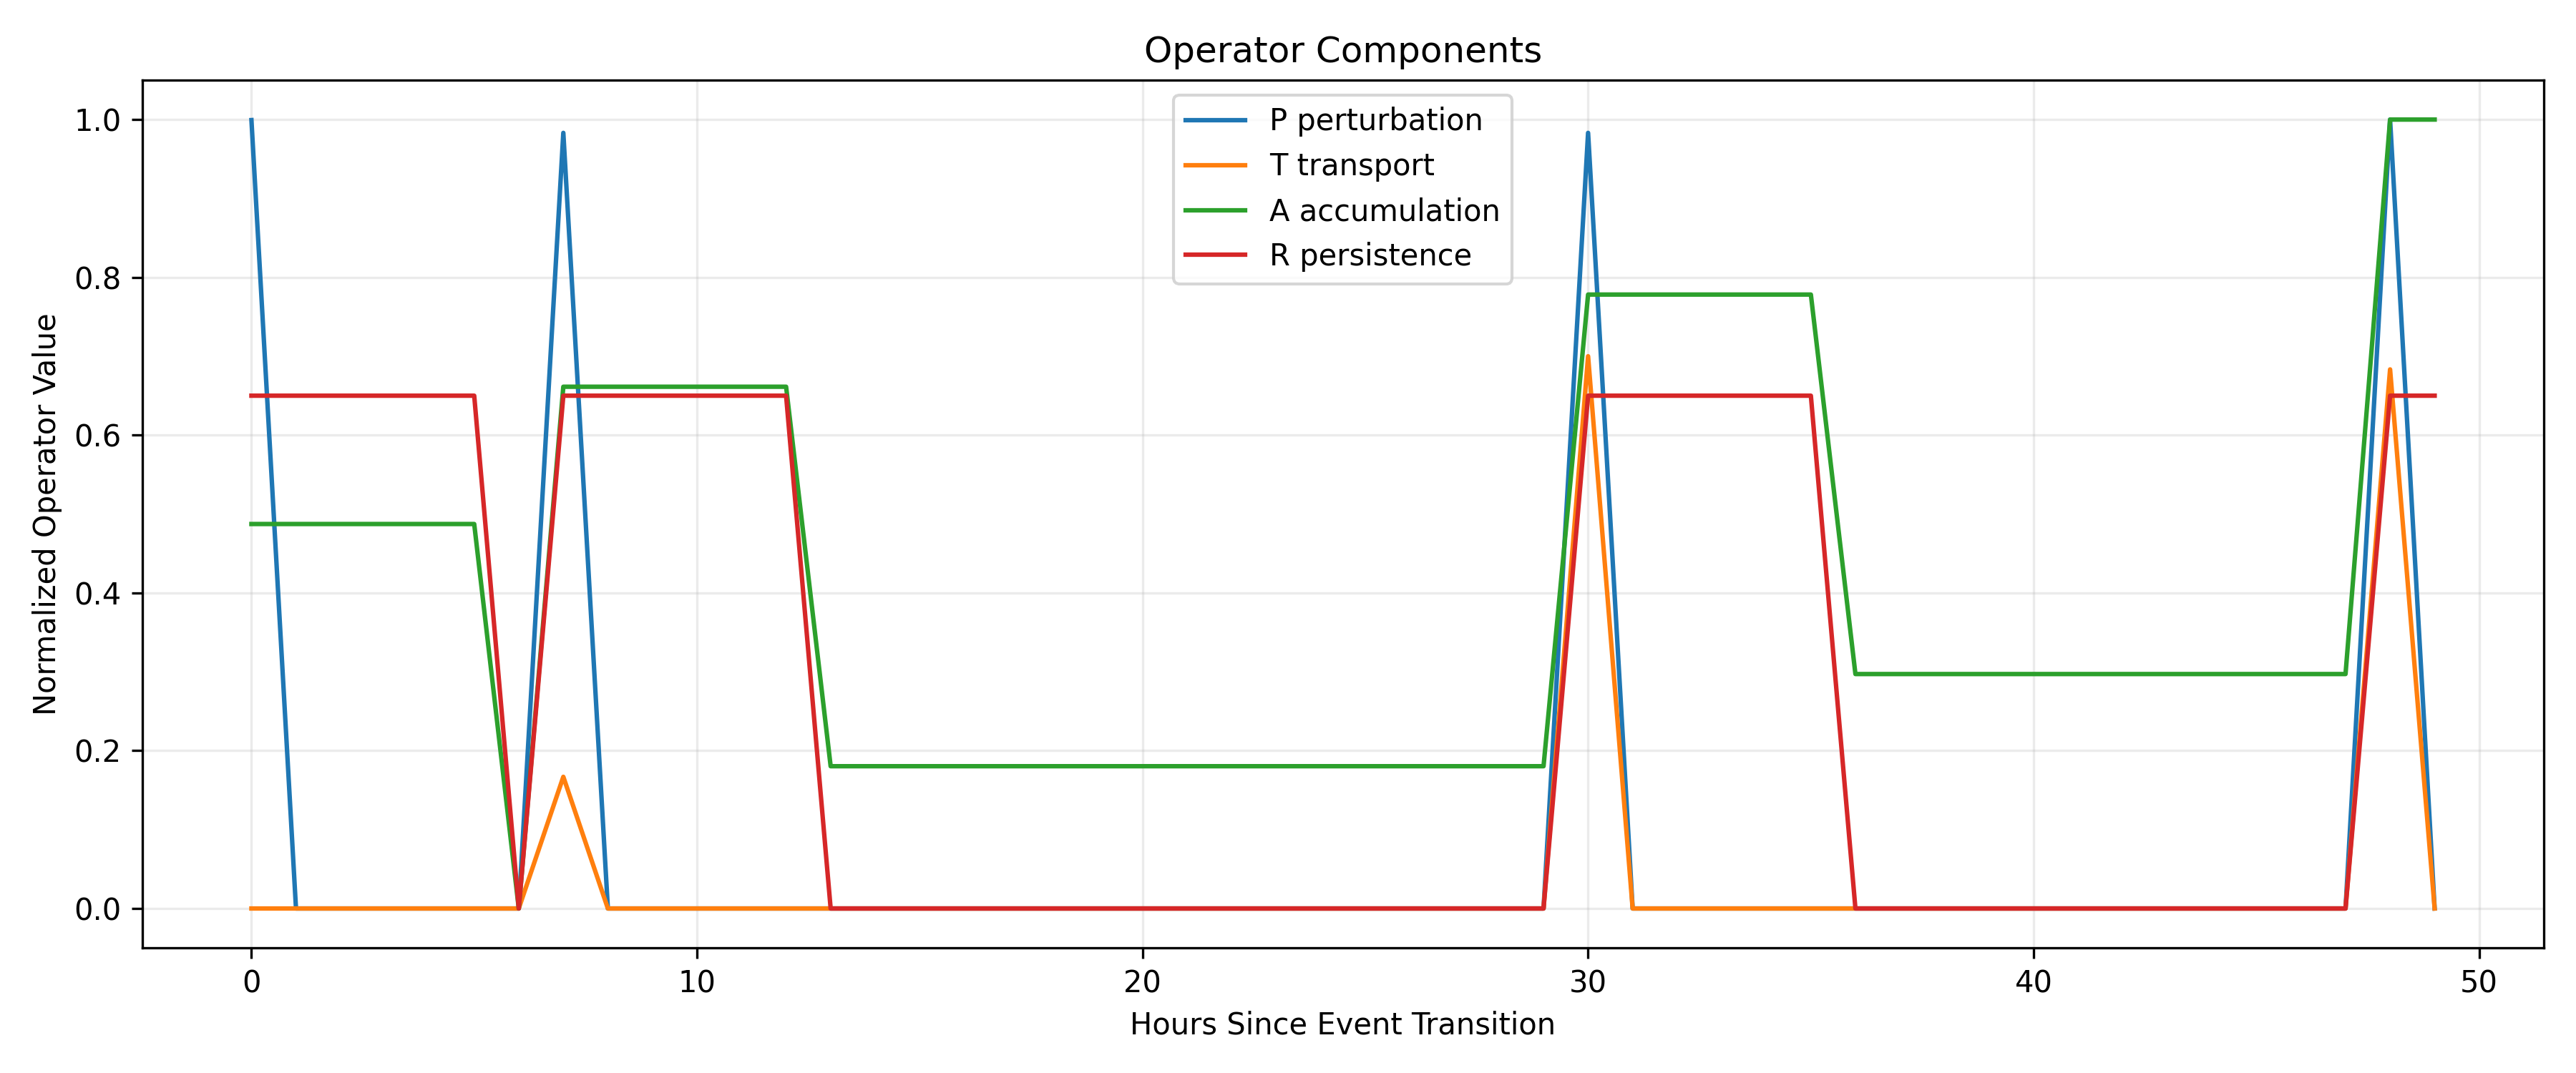

Saved: FUNt_Transition_Engine/venezuela_us6000t7zp_engine_test/figures/operator_components.png


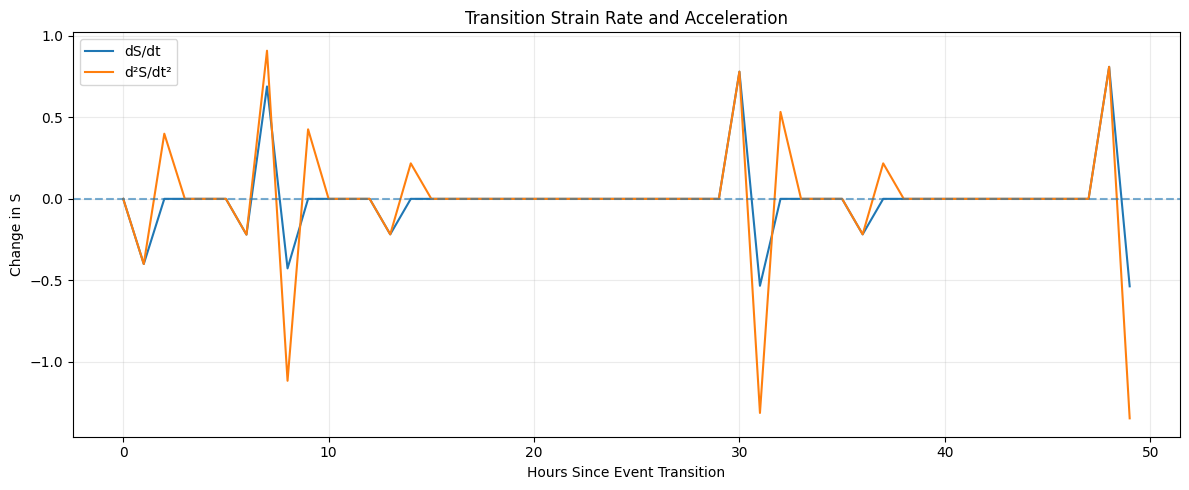

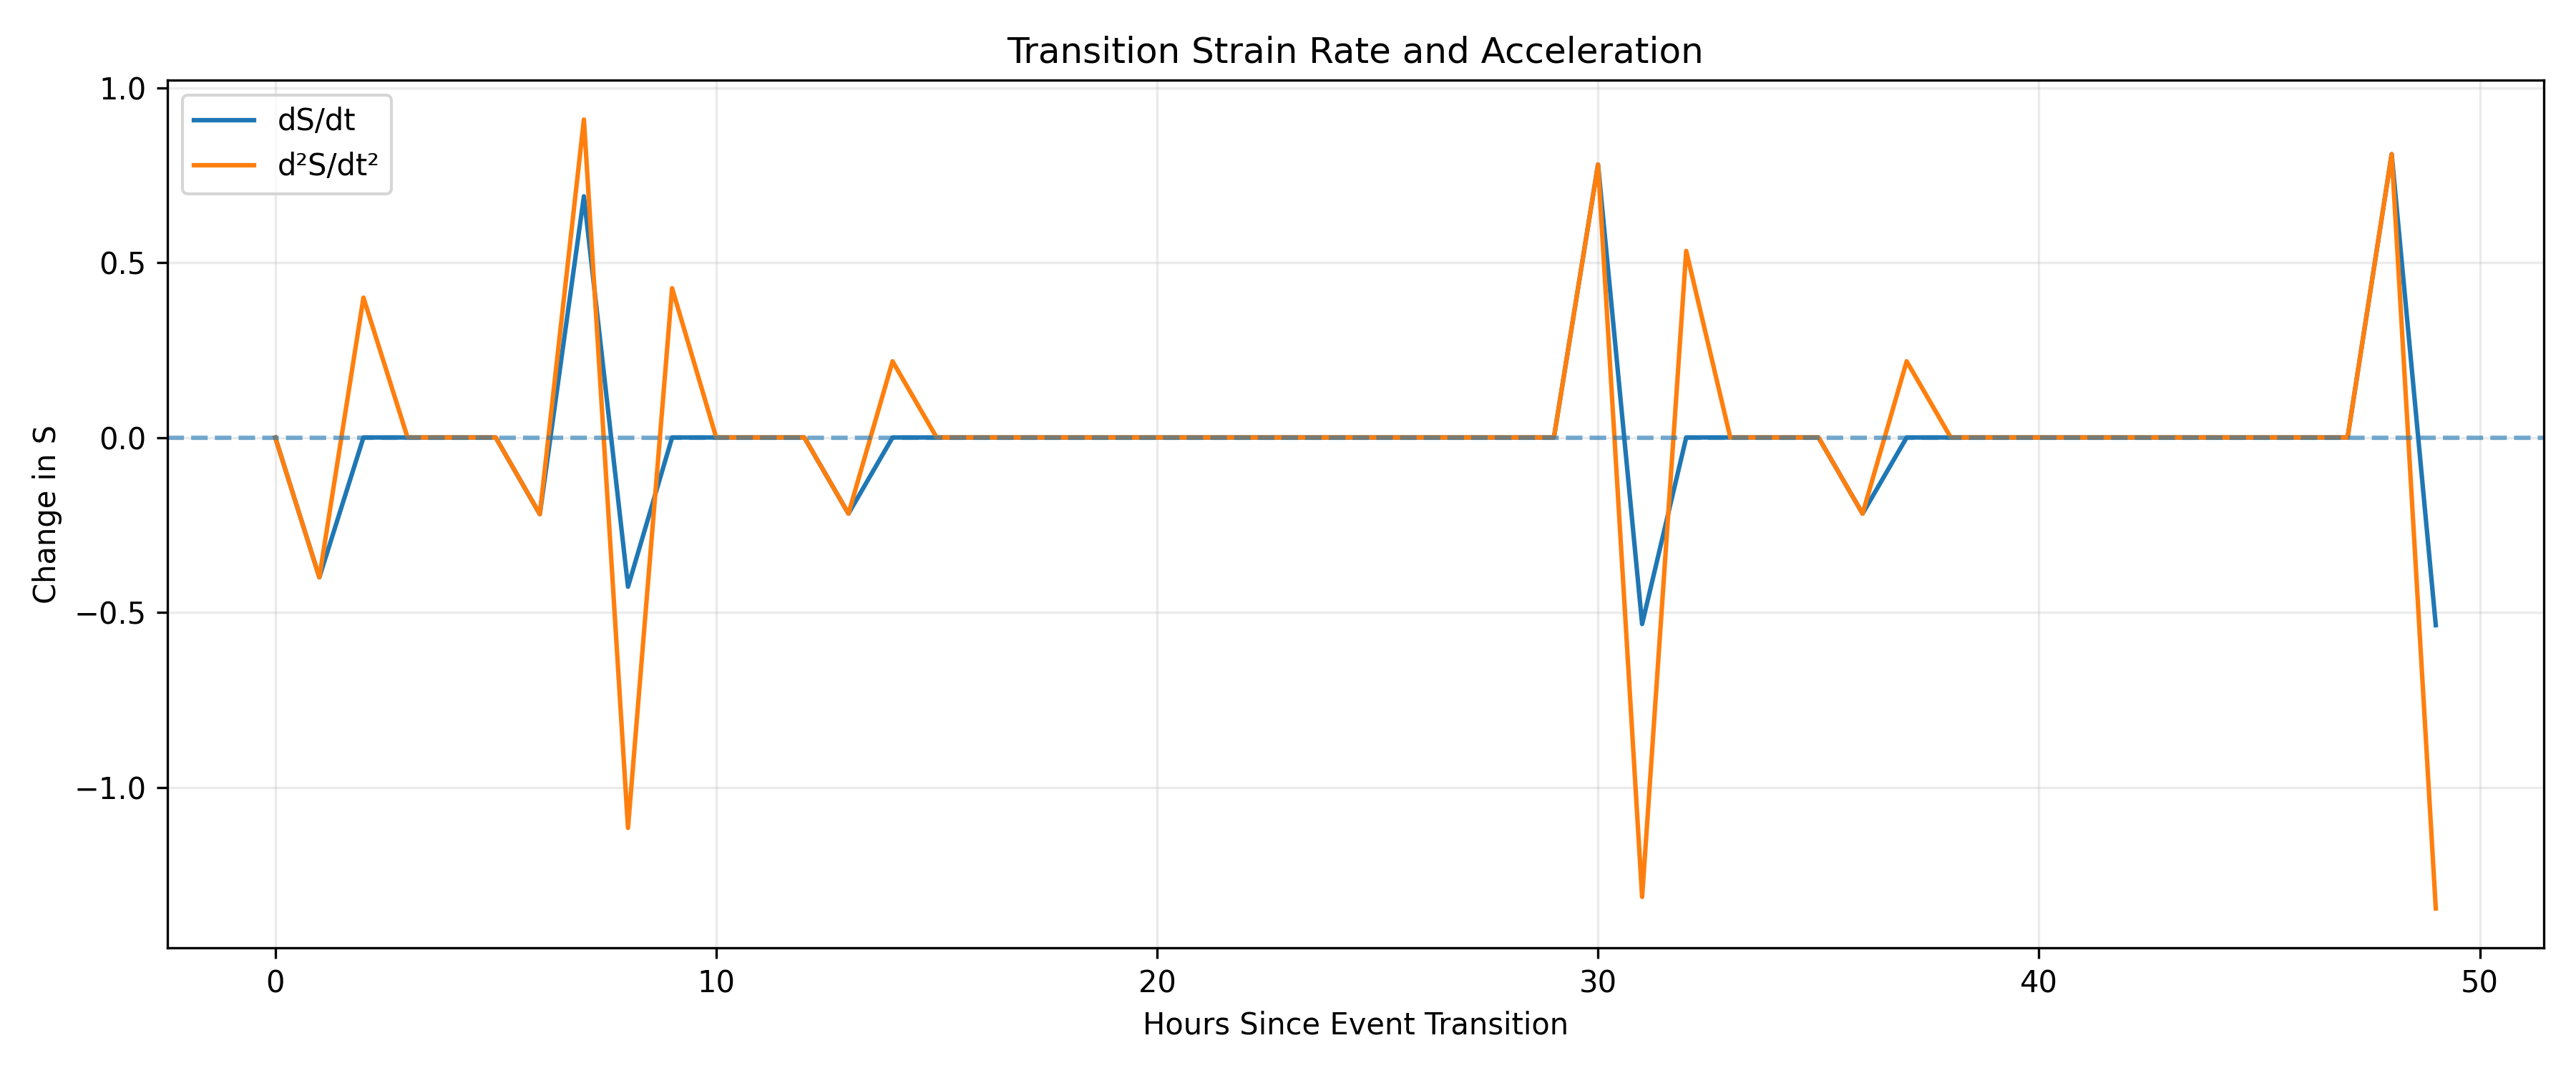

Saved: FUNt_Transition_Engine/venezuela_us6000t7zp_engine_test/figures/S_derivatives.png


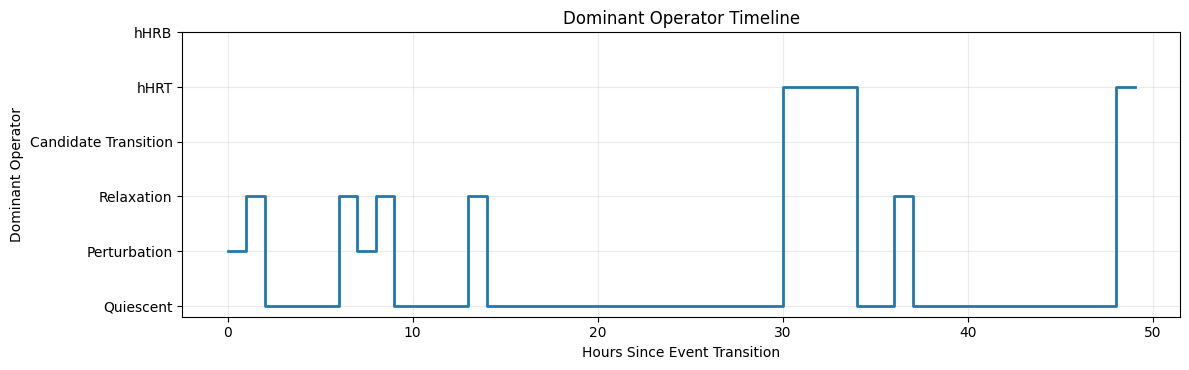

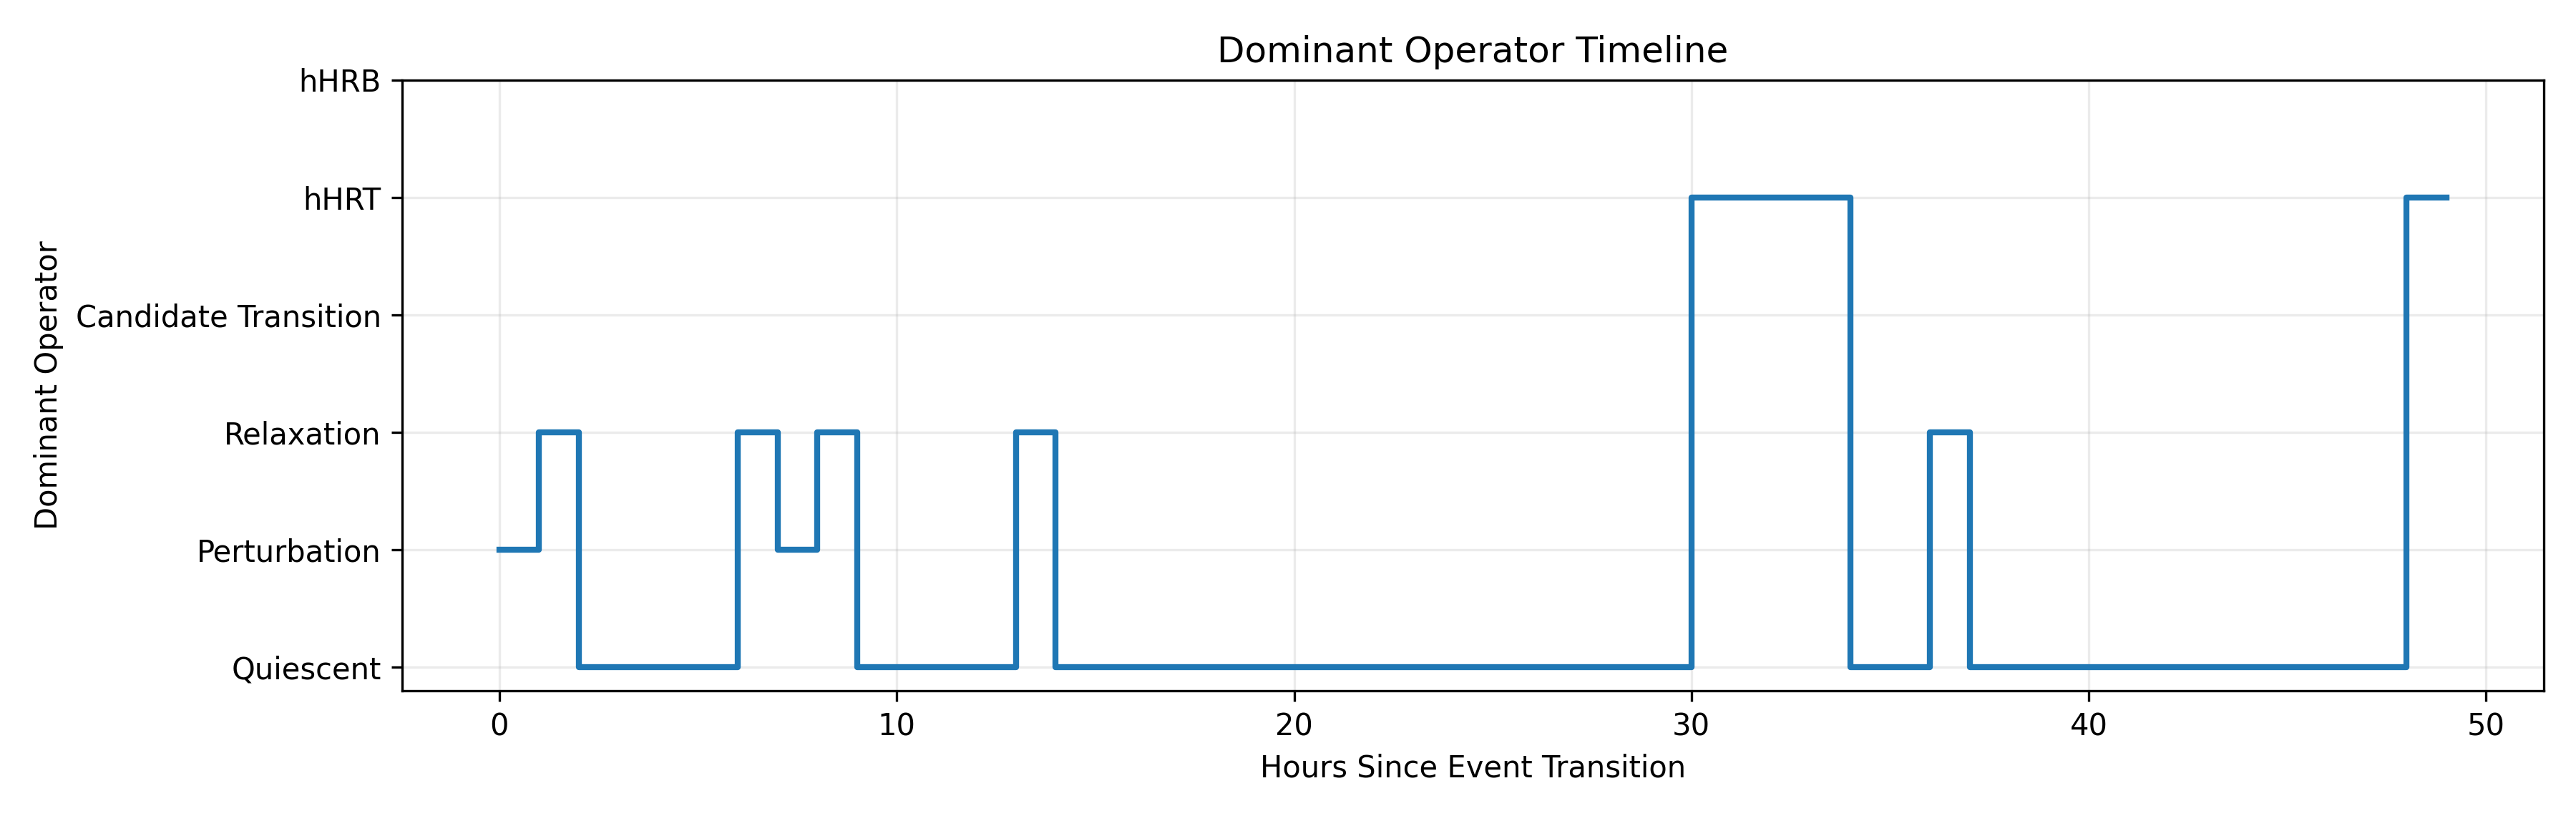

Saved: FUNt_Transition_Engine/venezuela_us6000t7zp_engine_test/figures/dominant_operator_timeline.png


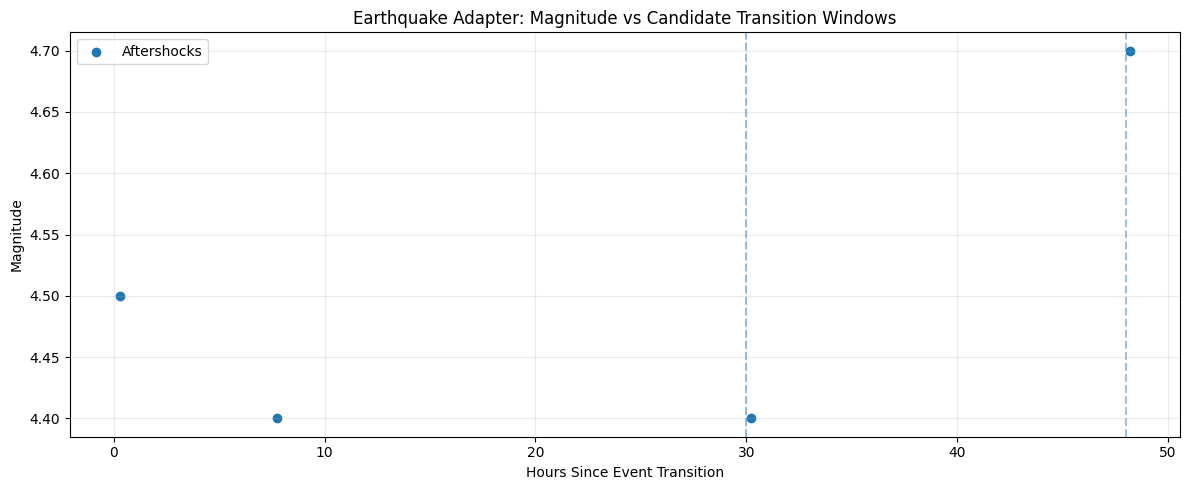

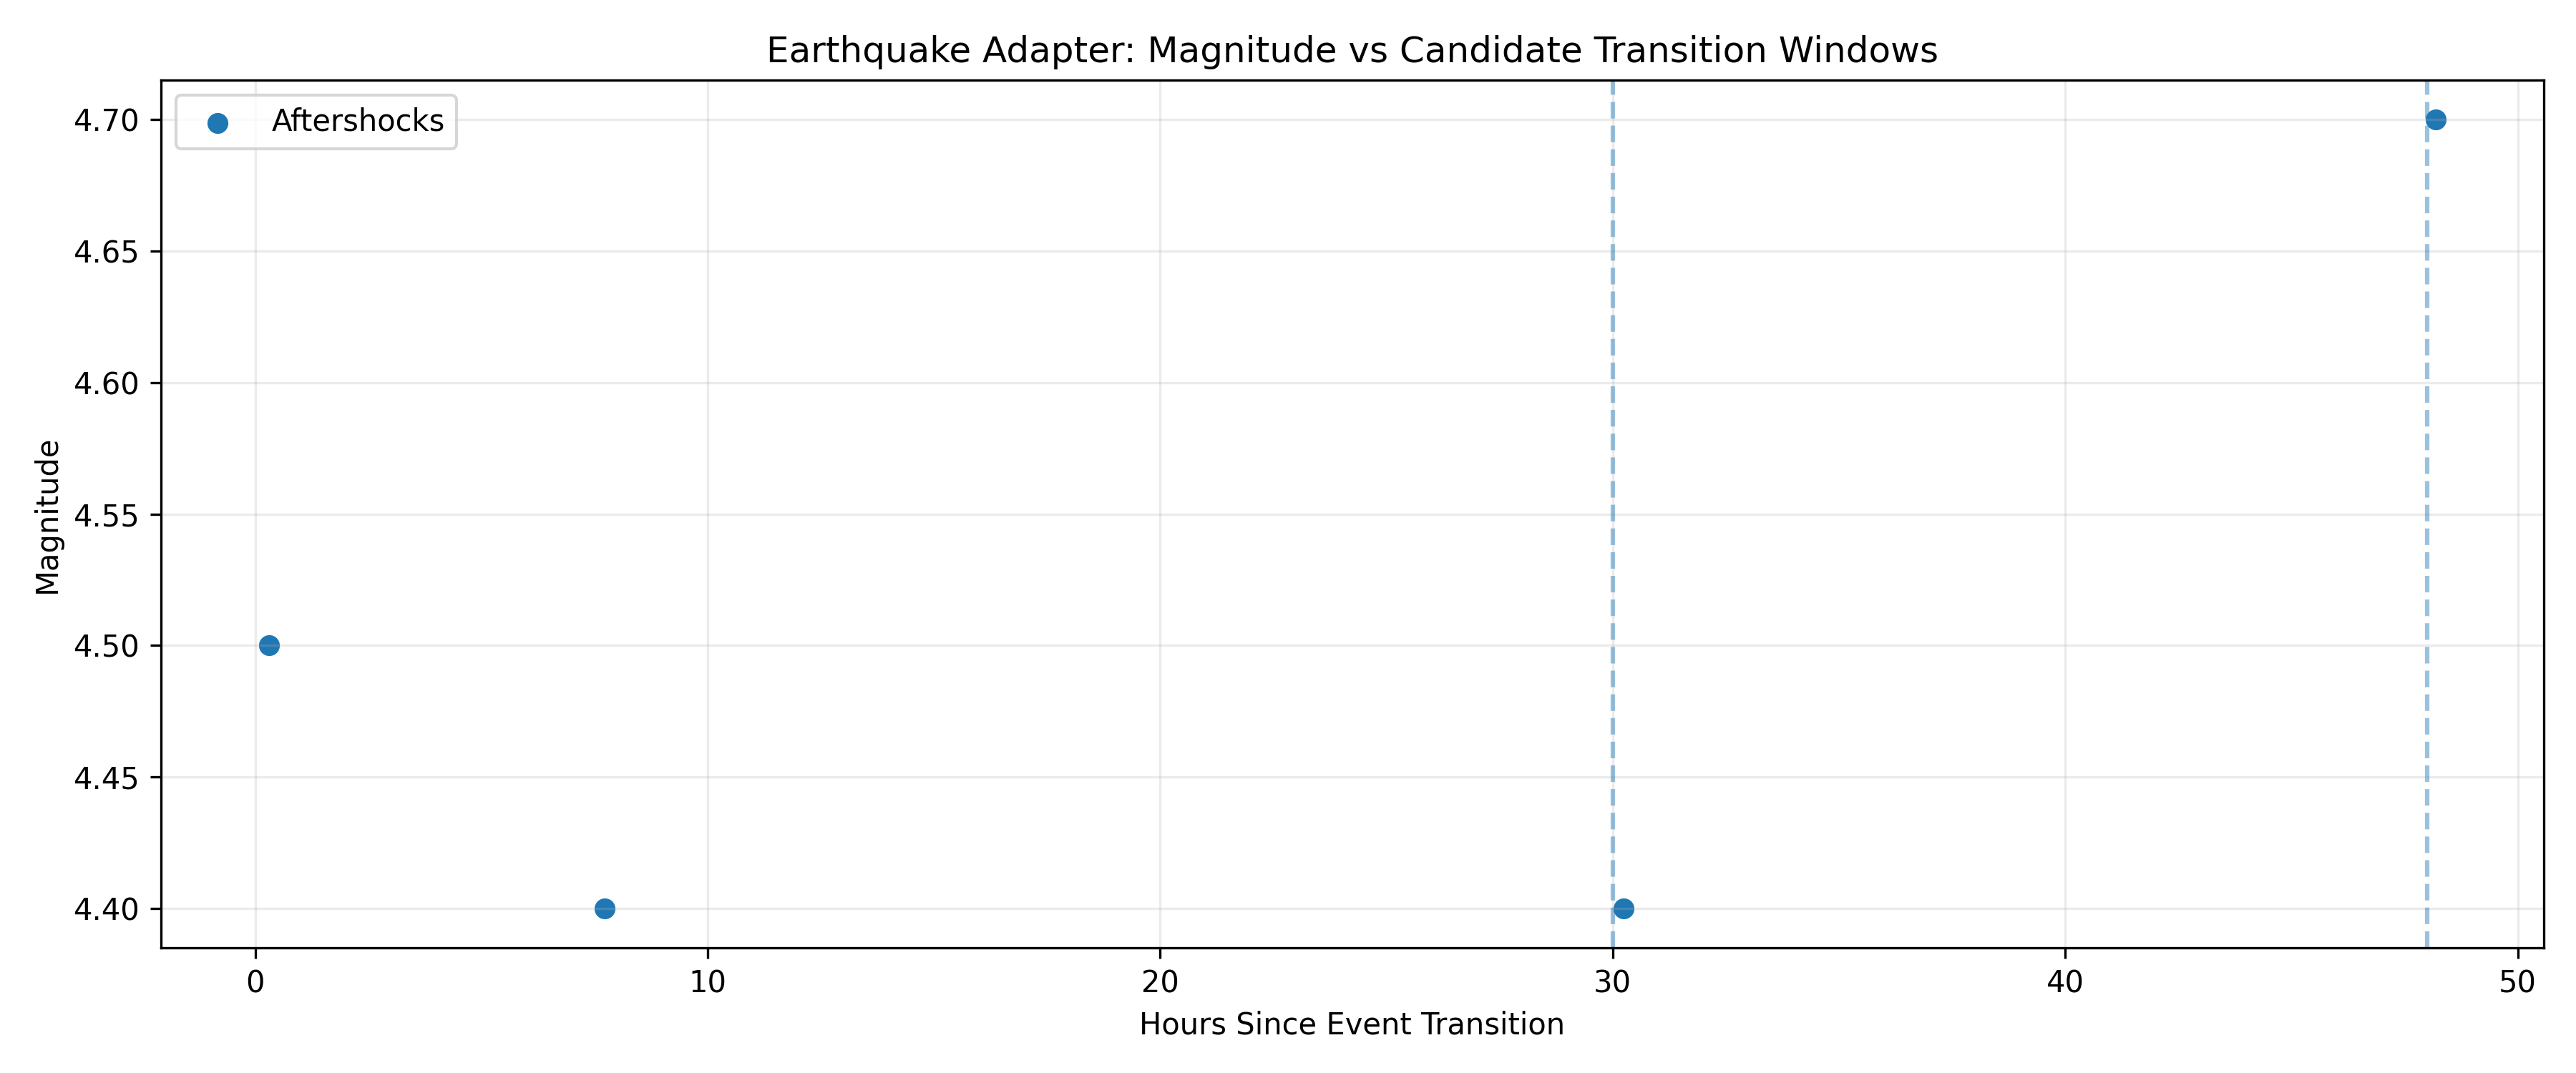

Saved: FUNt_Transition_Engine/venezuela_us6000t7zp_engine_test/figures/earthquake_magnitude_overlay.png


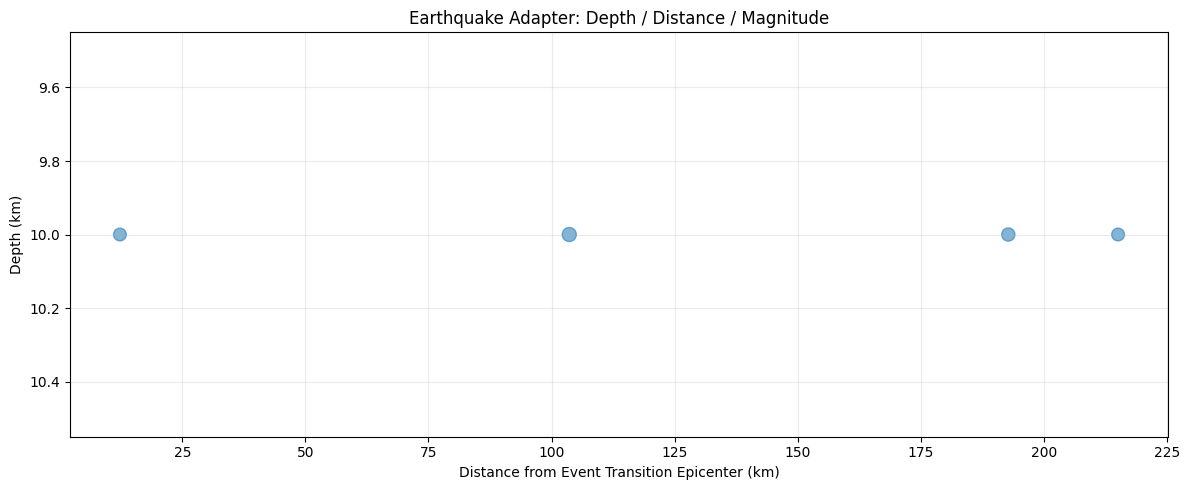

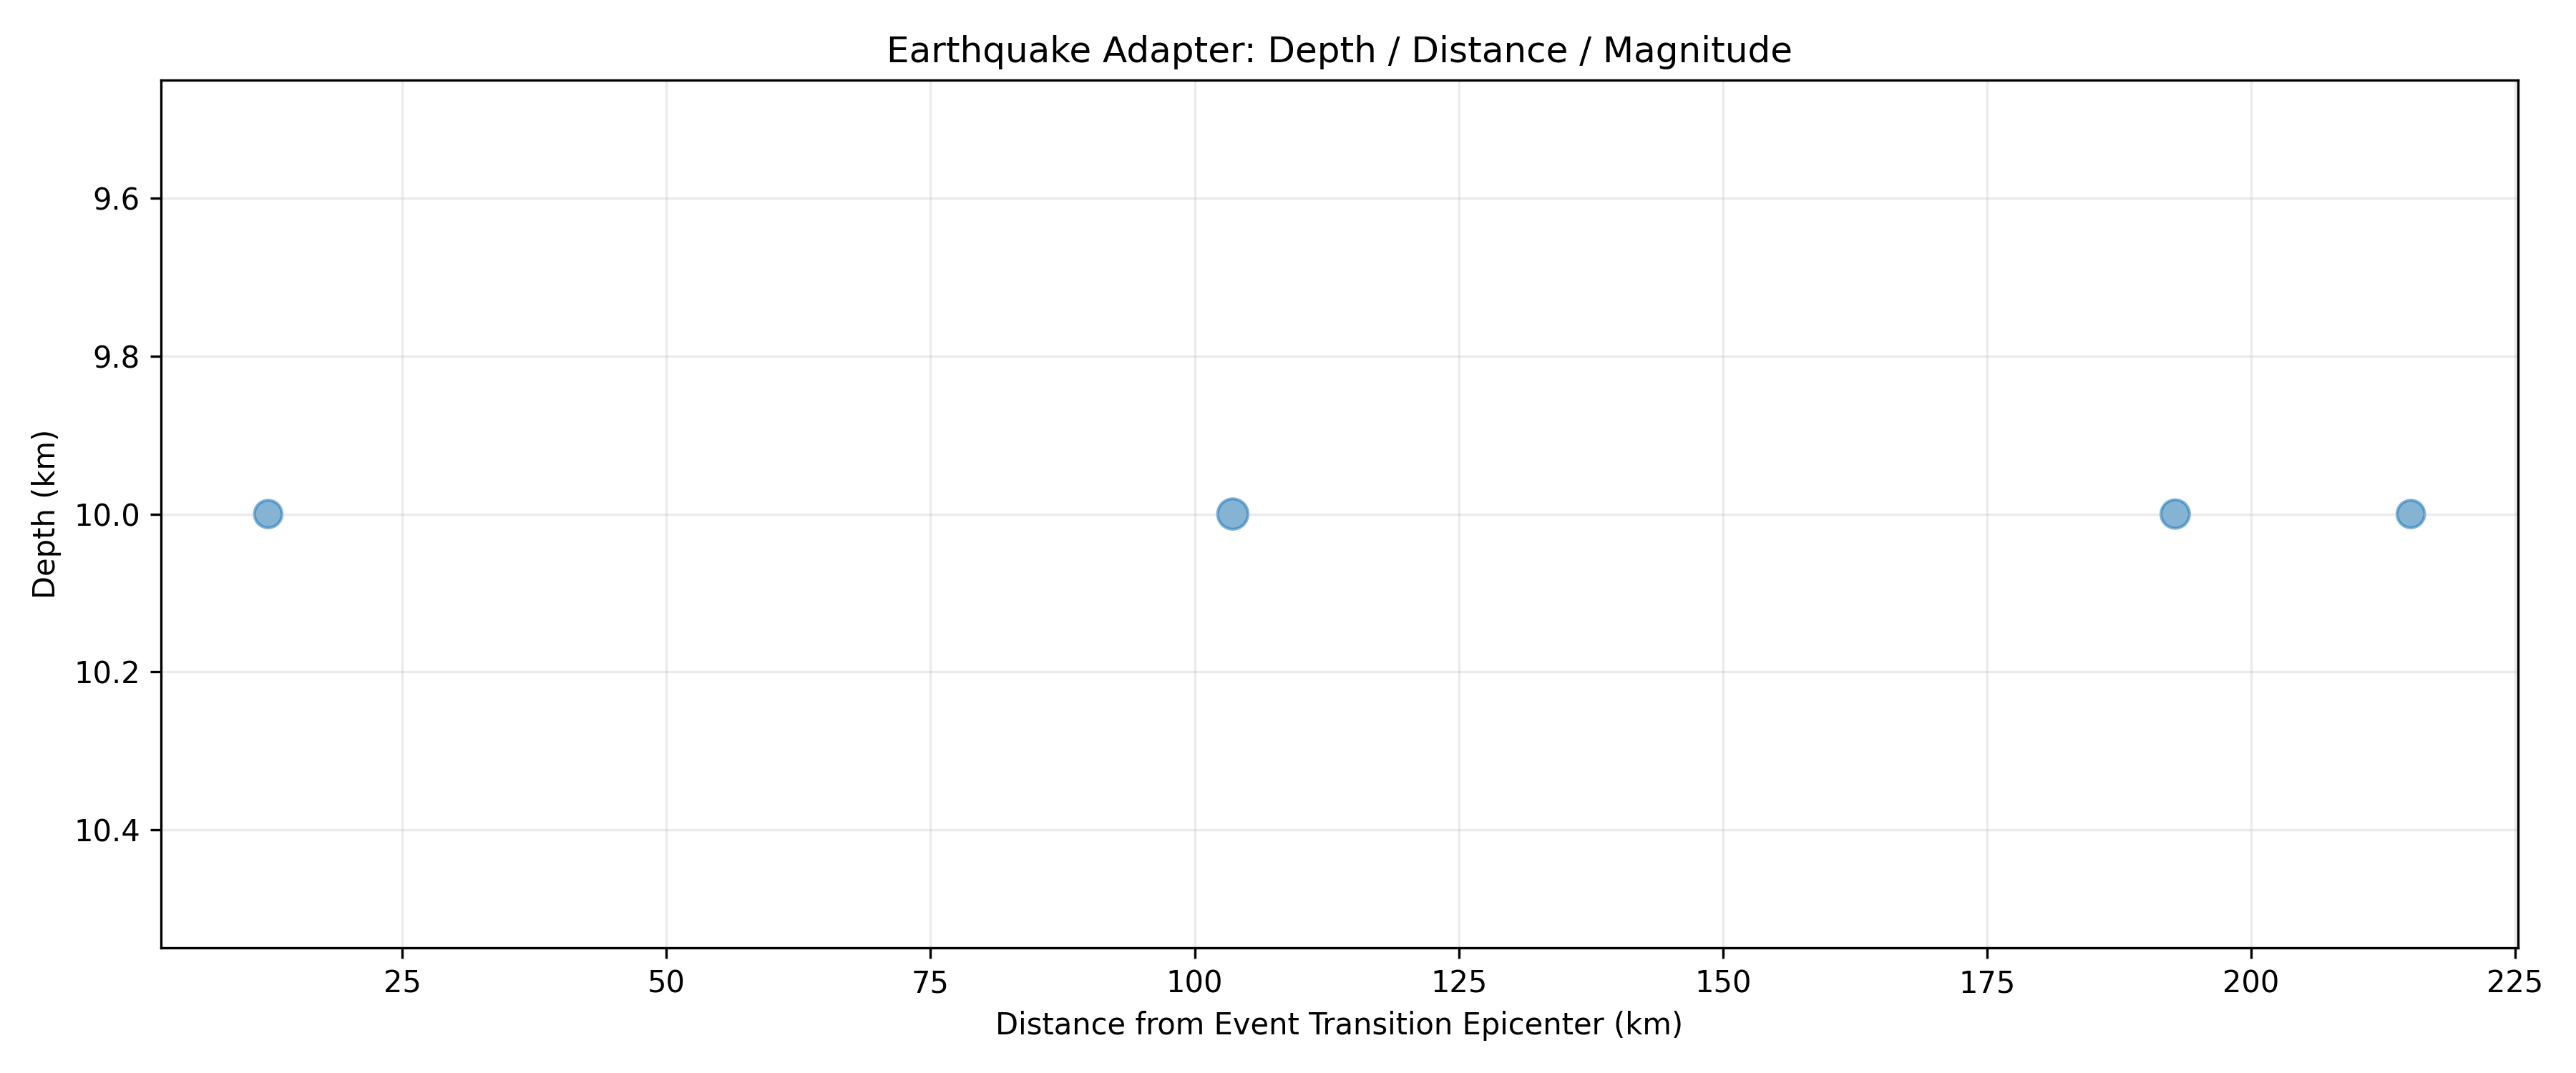

Saved: FUNt_Transition_Engine/venezuela_us6000t7zp_engine_test/figures/earthquake_depth_distance_magnitude.png
Figure count: 6


In [8]:
def savefig(name):
    path = os.path.join(FIG_DIR, name)
    plt.tight_layout()
    plt.savefig(path, dpi=300)
    plt.show()
    if IN_IPYTHON:
        try:
            display(Image(filename=path))
        except Exception:
            pass
    print("Saved:", path)
    return path

figure_paths = []

if df_engine.empty:
    print("No figures generated because no event data was available.")
else:
    # 1. Transition strain S
    plt.figure(figsize=(12, 5))
    plt.plot(df_engine["hour"], df_engine["S_transition_strain"], linewidth=2, label="S transition strain")
    plt.axhline(CONFIG["candidate_transition_S_threshold"], linestyle="--", alpha=0.7, label="Candidate threshold")
    for h in engine_diagnostics.get("candidate_transition_hours", []):
        plt.axvline(h, linestyle="--", alpha=0.45)
    plt.xlabel("Hours Since Event Transition")
    plt.ylabel("S")
    plt.title("FUNt Transition Engine: S(t)")
    plt.legend()
    plt.grid(True, alpha=0.25)
    figure_paths.append(savefig("S_transition_strain.png"))

    # 2. Operator components
    plt.figure(figsize=(12, 5))
    plt.plot(df_engine["hour"], df_engine["P_perturbation"], label="P perturbation")
    plt.plot(df_engine["hour"], df_engine["T_transport"], label="T transport")
    plt.plot(df_engine["hour"], df_engine["A_accumulation"], label="A accumulation")
    plt.plot(df_engine["hour"], df_engine["R_persistence"], label="R persistence")
    plt.xlabel("Hours Since Event Transition")
    plt.ylabel("Normalized Operator Value")
    plt.title("Operator Components")
    plt.legend()
    plt.grid(True, alpha=0.25)
    figure_paths.append(savefig("operator_components.png"))

    # 3. S derivatives
    plt.figure(figsize=(12, 5))
    plt.plot(df_engine["hour"], df_engine["dS_dt"], label="dS/dt")
    plt.plot(df_engine["hour"], df_engine["d2S_dt2"], label="d²S/dt²")
    plt.axhline(0, linestyle="--", alpha=0.6)
    plt.xlabel("Hours Since Event Transition")
    plt.ylabel("Change in S")
    plt.title("Transition Strain Rate and Acceleration")
    plt.legend()
    plt.grid(True, alpha=0.25)
    figure_paths.append(savefig("S_derivatives.png"))

    # 4. Phase timeline
    phase_order = {"Quiescent": 0, "Perturbation": 1, "Relaxation": 2, "Candidate Transition": 3, "hHRT": 4, "hHRB": 5}
    phase_numeric = df_engine["dominant_operator"].map(phase_order).fillna(0)
    plt.figure(figsize=(12, 3.8))
    plt.step(df_engine["hour"], phase_numeric, where="post", linewidth=2)
    plt.yticks(list(phase_order.values()), list(phase_order.keys()))
    plt.xlabel("Hours Since Event Transition")
    plt.ylabel("Dominant Operator")
    plt.title("Dominant Operator Timeline")
    plt.grid(True, alpha=0.25)
    figure_paths.append(savefig("dominant_operator_timeline.png"))

    # 5. Earthquake-specific magnitude overlay
    if not df_events.empty:
        plt.figure(figsize=(12, 5))
        plt.scatter(df_events["hours_since_event_transition"], df_events["magnitude"], label="Aftershocks")
        for h in engine_diagnostics.get("candidate_transition_hours", []):
            plt.axvline(h, linestyle="--", alpha=0.45)
        plt.xlabel("Hours Since Event Transition")
        plt.ylabel("Magnitude")
        plt.title("Earthquake Adapter: Magnitude vs Candidate Transition Windows")
        plt.legend()
        plt.grid(True, alpha=0.25)
        figure_paths.append(savefig("earthquake_magnitude_overlay.png"))

        plt.figure(figsize=(12, 5))
        plt.scatter(df_events["distance_km"], df_events["depth_km"], s=(df_events["magnitude"]**3), alpha=0.55)
        plt.gca().invert_yaxis()
        plt.xlabel("Distance from Event Transition Epicenter (km)")
        plt.ylabel("Depth (km)")
        plt.title("Earthquake Adapter: Depth / Distance / Magnitude")
        plt.grid(True, alpha=0.25)
        figure_paths.append(savefig("earthquake_depth_distance_magnitude.png"))

save_json(os.path.join(RUN_DIR, "figure_audit.json"), {"figure_count": len(figure_paths), "figures": figure_paths})
print("Figure count:", len(figure_paths))


## 8. Summary Report

In [9]:
maturity = catalog_maturity(len(df_events), CONFIG["small_catalog_warning_threshold"])
small_catalog_warning = len(df_events) < CONFIG["small_catalog_warning_threshold"]

summary_lines = []
summary_lines.append("FUNt Transition Engine v0.1")
summary_lines.append("Domain-neutral core + Earthquake Adapter")
summary_lines.append("Historical / descriptive analysis only. No prediction performed.")
summary_lines.append("")
summary_lines.append("==== Event Transition Anchor ====")
for k, v in EVENT_TRANSITION.items():
    summary_lines.append(f"{k}: {v}")
summary_lines.append("")
summary_lines.append("==== Clock Reference ====")
for k, v in clock_reference.items():
    summary_lines.append(f"{k}: {v}")
summary_lines.append("")
summary_lines.append("==== Configuration ====")
summary_lines.append(json.dumps(CONFIG, indent=2))
summary_lines.append(f"Config SHA-256: {CONFIG_HASH}")
summary_lines.append("")
summary_lines.append("==== Acquisition Audit ====")
for k, v in acquisition_audit.items():
    summary_lines.append(f"{k}: {v}")
summary_lines.append(f"Catalog maturity: {maturity}")
summary_lines.append(f"Small catalog warning: {small_catalog_warning}")
if small_catalog_warning:
    summary_lines.append("Small-catalog warning: diagnostics are observational only and not statistically meaningful.")
summary_lines.append("")
summary_lines.append("==== Engine Diagnostics ====")
for k, v in engine_diagnostics.items():
    summary_lines.append(f"{k}: {v}")
summary_lines.append("")
summary_lines.append("==== Figures ====")
for p in figure_paths:
    summary_lines.append(p)
summary_lines.append("")
summary_lines.append("==== Audit Footer ====")
summary_lines.append(f"Engine Version: {CONFIG['engine_version']}")
summary_lines.append(f"Domain Adapter: {CONFIG['adapter_version']}")
summary_lines.append(f"Prediction performed: {CONFIG['prediction_mode']}")
summary_lines.append("NO PREDICTION PERFORMED. This is a historical transition-engine run only.")
summary_lines.append("h3π is retained only as an audit reference; candidate transitions are derived from S-threshold crossing.")

summary_txt = os.path.join(RUN_DIR, "summary_report.txt")
write_text(summary_txt, "\n".join(summary_lines))
print("Saved:", summary_txt)
print("\n".join(summary_lines[:80]))


Saved: FUNt_Transition_Engine/venezuela_us6000t7zp_engine_test/summary_report.txt
FUNt Transition Engine v0.1
Domain-neutral core + Earthquake Adapter
Historical / descriptive analysis only. No prediction performed.

==== Event Transition Anchor ====
event_id: us6000t7zp
place: 28 km SE of Yumare, Venezuela
magnitude: 7.5
time_ms: 1782338711566
time_utc: 2026-06-24 22:05:11.566000+00:00
longitude: -68.4716
latitude: 10.4351
depth_km: 10
url: https://earthquake.usgs.gov/earthquakes/eventpage/us6000t7zp
time_local: 2026-06-24 18:05:11.566000-04:00

==== Clock Reference ====
clock_zone: Venezuela Time / VET
iana_time_zone: America/Caracas
event_transition_local_time: 2026-06-24 06:05:11 PM -0400
current_local_time_at_runtime: 2026-06-26 07:39:24 PM -0400
realtime_hours_since_event_transition: 49.570275271944446
realtime_days_since_event_transition: 2.0654281363310183

==== Configuration ====
{
  "engine_version": "FUNt Transition Engine v0.1",
  "run_label": "venezuela_us6000t7zp_engine_t

## 9. Zip Run Folder

In [10]:
zip_path = f"{CONFIG['run_label']}_FUNt_Transition_Engine_v0_1.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for root, dirs, files_in_dir in os.walk(RUN_DIR):
        for filename in files_in_dir:
            full_path = os.path.join(root, filename)
            arcname = os.path.relpath(full_path, ROOT_DIR)
            z.write(full_path, arcname)

print("Saved zip:", zip_path)

if IN_COLAB:
    files.download(zip_path)


Saved zip: venezuela_us6000t7zp_engine_test_FUNt_Transition_Engine_v0_1.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Audit Footer

This notebook is the first **FUNt Transition Engine** implementation.

The engine core is domain-neutral. The earthquake adapter translates USGS observations into the engine's operator inputs.

**No prediction is performed.**

Prediction, if ever justified, belongs in a separate silo after the transition engine demonstrates reproducible behavior across many historical runs and domains.
